# Gradient Decent 

this is used to estimate parameter in learning algorithmns 

## General Algorithmn

1) Take the derivative for the loss function, for each parameter in it.
2) Pick random values for the paramater to start with.
3) Plug the paramter values into the derivatives
4) Calculate the step size: step size = slop * learning rate
5) calculate the new parameter: new parameter = old parameter - step size
6) repeat from step 3 untill step size is really small or you exceed the set number of steps 

## Gradient Descent

Start with some $\theta$ (say $\theta = \vec{0}$)
Keep changing $\theta$ to reduce $J(\theta)$

**Update Rule:**
$$\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta)$$
for $j = 0, 1, 2, \dots, n$

> **Note:** $\alpha$ represents the learning rate (usually a small value like **0.01**).

### Deriving the Gradient
Let's find the partial derivative of the cost function $J(\theta)$ using Mean Squared Error:

$$\frac{\partial}{\partial \theta_j} J(\theta) = \frac{\partial}{\partial \theta_j} \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2$$

$$= \frac{1}{2m} \sum_{i=1}^{m} \left( \frac{\partial}{\partial \theta_j} (h_\theta(x^{(i)}) - y^{(i)})^2 \right)$$

$$= \frac{1}{2m} \sum_{i=1}^{m} \left[ 2 \cdot (h_\theta(x^{(i)}) - y^{(i)}) \cdot \frac{\partial}{\partial \theta_j} (h_\theta(x^{(i)}) - y^{(i)}) \right]$$

$$= \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) \cdot \frac{\partial}{\partial \theta_j} \left( \theta_0 x_0 + \theta_1 x_1 + \dots + \theta_n x_n - y^{(i)} \right)$$

$$= \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) \cdot x_j^{(i)}$$

### Final Gradient Descent Algorithm
Substitute the derived derivative back into the update rule:

$$\theta_j := \theta_j - \alpha \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) \cdot x_j^{(i)}$$

*   **Repeat until convergence.**
*   **Update simultaneously** for $j = 0, 1, 2, 3, \dots, n$

### Cost Function Shape & Learning Rate ($\alpha$)
For linear regression, the cost function $J(\theta)$ looks like a convex, bowl-shaped surface (visualized as a 3D bowl or a 2D contour plot), meaning it has one global minimum.

**Choosing the right learning rate ($\alpha$):**
*   If $\alpha$ is **too large**, you will overshoot the minimum and the algorithm may fail to converge (or even diverge, requiring lots of iterations).
*   If $\alpha$ is **too small**, it will require a lot of iterations and converge very slowly.

# Visual Plots 

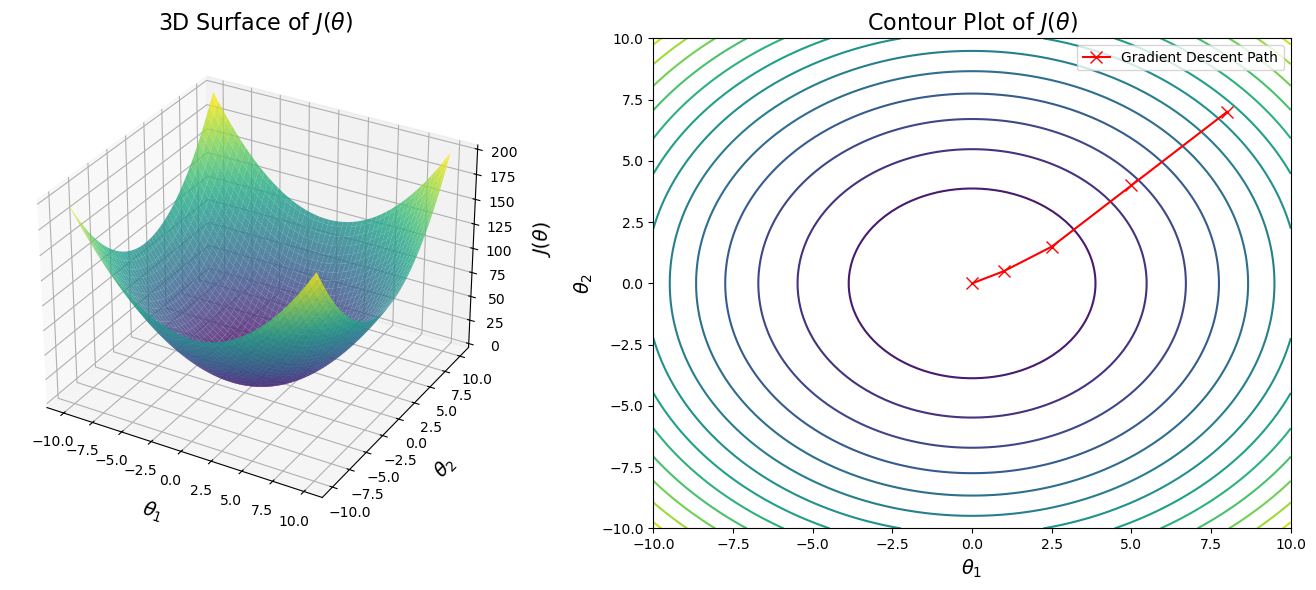

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# define the parameter range for theta_1 and theta_2
theta1 = np.linspace(-10, 10, 100)
theta2 = np.linspace(-10, 10, 100)
T1, T2 = np.meshgrid(theta1, theta2)

# define a convex cost function J(Theta) for visualization (a simple bowl shape)
J = T1**2 + T2**2

# Set up the figure side-by-side
fig = plt.figure(figsize=(14, 6))

# 1. 3D Surface Plot 
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(T1, T2, J, cmap='viridis', alpha=0.8, edgecolor='none')
ax1.set_xlabel(r'$\theta_1$', fontsize=14, labelpad=10)
ax1.set_ylabel(r'$\theta_2$', fontsize=14, labelpad=10)
ax1.set_zlabel(r'$J(\theta)$', fontsize=14, labelpad=10)
ax1.set_title(r'3D Surface of $J(\theta)$', fontsize=16)

# 2. 2D Contour Plot (
ax2 = fig.add_subplot(122)
contour = ax2.contour(T1, T2, J, levels=15, cmap='viridis')
ax2.set_xlabel(r'$\theta_1$', fontsize=14)
ax2.set_ylabel(r'$\theta_2$', fontsize=14)
ax2.set_title(r'Contour Plot of $J(\theta)$', fontsize=16)

path_t1 = [8, 5, 2.5, 1, 0]
path_t2 = [7, 4, 1.5, 0.5, 0]
ax2.plot(path_t1, path_t2, marker='x', color='red', linestyle='-', markersize=8, label='Gradient Descent Path')
ax2.legend()

plt.tight_layout()
plt.show()

### Why Linear Regression Has Only One Global Minimum

The cost function for linear regression, Mean Squared Error (MSE), is mathematically guaranteed to be a **convex function**. 

Here is what that means for your model:
*   **The Math:** The MSE formula is a quadratic equation. 
*   **The Shape:** When plotted in 3D, a convex function always forms a perfectly smooth, bowl-like surface. 
*   **The Result:** Because the bowl is smooth and continuously curving upward, it does not have any "fake bottoms" (local minima) for the gradient descent algorithm to get stuck in. There is only one true lowest point, which is the **global minimum**.

> **The Exception (Perfect Multicollinearity):**
> The only time you do not have a single, unique dot at the bottom is if two of your features are exact duplicates or perfectly correlated (for example, having one feature for "size in feet" and another for "size in inches"). In this case, the bottom of the bowl stretches out into a flat valley. However, gradient descent will still never get stuck in a "fake" minimum; anywhere along the bottom of that valley is still a valid global minimum!